<a href="https://colab.research.google.com/github/oliverclaypole/7BUIS010W/blob/main/Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings

# quiet down the warnings so we don't get spam
warnings.filterwarnings('ignore')


# TASK A — DATA COLLECTION & FEATURE ENGINEERING


# A.1  Pull the S&P 500 constituent list from Wikipedia
wiki_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# need this header or we get a 403 error from Wikipedia
req_headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# first table on the page has the constituents
wiki_tables = pd.read_html(wiki_url, storage_options=req_headers)
sp500_df = wiki_tables[0]

print("S&P 500 table loaded:")
print(sp500_df.head())
print(f"Total companies in table: {len(sp500_df)}")


tickers = [t.replace('.', '-') for t in sp500_df['Symbol'].tolist()]

print(f"\nTotal tickers extracted: {len(tickers)}")
print(f"Sample tickers: {tickers[:10]}")


S&P 500 table loaded:
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  
Total companies in table: 503

Tot

In [2]:
# A.2  Download three years of daily closing prices

# We pull data from Jan 2022 → Jan 2025, giving us roughly 756
# trading days — enough for stable beta and volatility estimates.

START_DATE = '2022-01-01'
END_DATE   = '2025-01-01'

print("Downloading S&P 500 price data (this takes 2–4 minutes)...")

import logging
logging.getLogger('yfinance').setLevel(logging.CRITICAL)   # suppress delisted-ticker warning

stock_data = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # returns split/dividend-adjusted prices under 'Close'
    progress=True
)

# We only need the closing price column for our calculations
stock_prices = stock_data['Close'].copy()

# Drop tickers that returned no data at all (e.g. delisted stocks like Q and SNDK)
stock_prices = stock_prices.dropna(axis=1, how='all')

print(f"\nRaw download shape: {stock_prices.shape}")
print(f"Missing values before cleaning: {stock_prices.isna().sum().sum():,}")

[*********************100%***********************]  503 of 503 completed



Raw download shape: (753, 501)
Missing values before cleaning: 2,145


In [3]:
# A.3  Clean the data — drop incomplete tickers, fill gaps

# Some stocks were only added to the S&P 500 after our start
# date, so they'll have huge chunks of missing data. We drop any
# ticker missing more than 5% of all trading days.

total_days         = stock_prices.shape[0]
missing_per_ticker = stock_prices.isna().sum()

threshold      = 0.05 * total_days   # 5% of trading days
tickers_to_drop = missing_per_ticker[missing_per_ticker > threshold].index.tolist()

print(f"Trading days in dataset  : {total_days}")
print(f"Tickers before cleaning  : {stock_prices.shape[1]}")
print(f"Tickers dropped (>5% NaN): {len(tickers_to_drop)}")
print(f"Dropped: {tickers_to_drop}")

# Remove the problematic tickers entirely
stock_prices_clean = stock_prices.drop(columns=tickers_to_drop)

# For any small remaining gaps (e.g. a single missed trading day),
# forward-fill first, then back-fill to catch any gaps at the very start.
stock_prices_clean = stock_prices_clean.ffill().bfill()

print(f"\nTickers after cleaning   : {stock_prices_clean.shape[1]}")
print(f"Remaining NaN values     : {stock_prices_clean.isna().sum().sum()}")
print(f"Final shape              : {stock_prices_clean.shape}")
stock_prices_clean.head()


Trading days in dataset  : 753
Tickers before cleaning  : 501
Tickers dropped (>5% NaN): 5
Dropped: ['GEHC', 'GEV', 'KVUE', 'SOLV', 'VLTO']

Tickers after cleaning   : 496
Remaining NaN values     : 0
Final shape              : (753, 496)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103668,114.894058,172.679993,127.545830,42.362530,380.485352,564.369995,164.526505,60.037273,...,33.979378,85.125771,59.164799,54.760239,110.957481,164.029999,125.887215,120.797729,583.900024,223.051041
2022-01-04,146.573685,175.843246,114.673454,170.800003,124.546150,42.914051,377.766296,554.000000,163.040497,61.151524,...,34.414909,84.854225,59.539257,56.820000,112.134529,156.330002,126.560310,122.023193,587.599976,214.559036
2022-01-05,144.062759,171.165817,115.275841,162.250000,123.986595,42.410072,371.113525,514.429993,160.523590,60.673988,...,33.560608,81.711815,60.122719,57.526684,110.606262,143.490005,124.955925,121.620949,558.179993,206.400635
2022-01-06,144.566864,168.308533,114.732834,159.750000,123.968208,42.657307,353.192261,514.119995,161.034409,61.213428,...,33.828617,82.090065,59.652462,58.879742,110.454369,144.660004,126.246834,120.610634,555.159973,207.220261
2022-01-07,140.718079,168.474838,114.435890,166.050003,124.353500,42.856995,346.418121,510.700012,156.808640,61.735180,...,33.786739,82.002792,60.174957,59.362362,109.571587,141.539993,124.799202,119.880951,530.859985,201.187210


In [4]:
# A.4  Calculate Daily Returns

# Formula: Daily Return = (Price_today - Price_yesterday) / Price_yesterday
# pandas .pct_change() does exactly this in one line.
# The very first row will always be NaN (no previous day to compare to),
# so we drop it immediately after.

daily_returns = stock_prices_clean.pct_change()
daily_returns.dropna(how='all', inplace=True)   # remove the empty opening row

print(f"Daily Returns shape: {daily_returns.shape}")
print(f"\nSample (first 5 rows, first 5 tickers):")
print(daily_returns.iloc[:5, :5].round(6))
print(f"\nAverage daily return across all stocks: {daily_returns.mean().mean()*100:.4f}%")


Daily Returns shape: (752, 496)

Sample (first 5 rows, first 5 tickers):
Ticker             A      AAPL      ABBV      ABNB       ABT
Date                                                        
2022-01-04 -0.033806 -0.012692 -0.001920 -0.010887 -0.023518
2022-01-05 -0.017131 -0.026600  0.005253 -0.050059 -0.004493
2022-01-06  0.003499 -0.016693 -0.004711 -0.015408 -0.000148
2022-01-07 -0.026623  0.000988 -0.002588  0.039437  0.003108
2022-01-10  0.000069  0.000116  0.011195 -0.032159 -0.002213

Average daily return across all stocks: 0.0441%


In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')


# A.5  Calculate Beta for every stock

# Beta measures how much a stock moves relative to the overall market.
# Beta > 1  →  stock amplifies market swings (more volatile)
# Beta < 1  →  stock is calmer than the market (more defensive)
# Formula: Beta = corr(stock_returns, index_returns) × (std_stock / std_index)
# Benchmark used: S&P 500 index  (^GSPC)

index_raw     = yf.download('^GSPC', start='2022-01-01', end='2025-01-01',
                             auto_adjust=True, progress=False)
index_returns = index_raw['Close'].pct_change().dropna()

# We extract .std() as a plain scalar — leaving it as a Series would
# cause shape-mismatch errors when we divide inside the loop below.
index_std = index_returns['^GSPC'].std()

# Line up stock dates with index dates so we're always comparing
# the same trading days
aligned_stocks, aligned_index = daily_returns.align(
    index_returns, join='inner', axis=0
)

beta_dict = {}
for ticker in aligned_stocks.columns:
    s = aligned_stocks[ticker].dropna()

    # We explicitly pull the '^GSPC' column so 'm' is always a clean
    # 1-D Series — avoids a subtle bug where corr() gets confused by a DataFrame.
    m = aligned_index.loc[s.index, '^GSPC']

    # Skip any stock with fewer than 30 data points — not enough to be meaningful
    if len(s) < 30:
        continue

    corr = s.corr(m)
    beta_dict[ticker] = round(corr * (s.std() / index_std), 4)

# Sort descending so the most market-sensitive stocks appear at the top
beta_series = pd.Series(beta_dict, name='Beta').sort_values(ascending=False)

print(f"Beta calculated for {len(beta_series)} stocks")
print(f"\nBeta summary:")
print(beta_series.describe().round(4))
print(f"\nTop 5 highest beta: \n{beta_series.head()}")
print(f"\nTop 5 lowest beta: \n{beta_series.tail()}")


Beta calculated for 496 stocks

Beta summary:
count    496.0000
mean       0.9437
std        0.4318
min        0.1332
25%        0.6330
50%        0.9117
75%        1.1557
max        3.2941
Name: Beta, dtype: float64

Top 5 highest beta: 
CVNA    3.2941
COIN    2.9610
XYZ     2.5448
NVDA    2.2685
APP     2.2619
Name: Beta, dtype: float64

Top 5 lowest beta: 
LMT    0.2439
HRL    0.2366
SJM    0.1966
CPB    0.1337
GIS    0.1332
Name: Beta, dtype: float64


In [6]:
# A.6  Calculate Annual Volatility

# Volatility = standard deviation of daily returns, scaled up to a
# yearly figure by multiplying by √252 (252 = trading days in a year).
# We then multiply by 100 to express it as a percentage.

annual_vol = (daily_returns.std() * np.sqrt(252) * 100).round(4)
annual_vol.name = 'Annual_Volatility_Pct'

print(f"Annual Volatility calculated for {len(annual_vol)} stocks")
print(f"\nVolatility summary (%):")
print(annual_vol.describe().round(4))
print(f"\nMost volatile stocks:")
print(annual_vol.sort_values(ascending=False).head())
print(f"\nLeast volatile stocks:")
print(annual_vol.sort_values().head())


Annual Volatility calculated for 496 stocks

Volatility summary (%):
count    496.0000
mean      31.4300
std       11.4803
min       15.6193
25%       24.0116
50%       28.5016
75%       35.7327
max      134.1039
Name: Annual_Volatility_Pct, dtype: float64

Most volatile stocks:
Ticker
CVNA    134.1039
COIN     95.3848
SMCI     90.1957
APP      78.8374
PLTR     69.0932
Name: Annual_Volatility_Pct, dtype: float64

Least volatile stocks:
Ticker
KO     15.6193
JNJ    16.3759
PEP    17.0397
MCD    17.3512
CL     17.3713
Name: Annual_Volatility_Pct, dtype: float64


In [7]:
# Consolidate all metrics into one master DataFrame

# We now bring together mean return, beta, and volatility into
# a single table, and attach each stock's GICS sector label so
# we can colour-code our plots later.

mean_return = (daily_returns.mean() * 100).round(6)
mean_return.name = 'Mean_Daily_Return_Pct'

# Build a ticker → sector lookup from the Wikipedia table we pulled in A.1
sector_map = sp500_df.set_index(
    sp500_df['Symbol'].str.replace('.', '-', regex=False)
)['GICS Sector'].to_dict()

metrics_df = pd.DataFrame({
    'Mean_Daily_Return_Pct' : mean_return,
    'Beta'                  : beta_series,
    'Annual_Volatility_Pct' : annual_vol
})
metrics_df['Sector'] = metrics_df.index.map(sector_map)

# Drop any rows where data is incomplete (e.g. sector label missing)
metrics_df.dropna(inplace=True)
metrics_df.index.name = 'Ticker'

print(f"Master metrics DataFrame: {metrics_df.shape}")
print(metrics_df.head(10))

# Save to CSV so Task B can load it independently without re-running everything
metrics_df.to_csv('sp500_metrics.csv')
print("\nSaved: sp500_metrics.csv")

Master metrics DataFrame: (496, 4)
        Mean_Daily_Return_Pct    Beta  Annual_Volatility_Pct  \
Ticker                                                         
A                   -0.000158  1.0248                29.6259   
AAPL                 0.059113  1.2107                27.0935   
ABBV                 0.060992  0.2991                21.9958   
ABNB                 0.007361  1.6663                46.7875   
ABT                 -0.010575  0.6723                21.7839   
ACGL                 0.116465  0.5698                25.3997   
ACN                  0.001063  1.0942                27.0331   
ADBE                -0.002166  1.4480                38.3083   
ADI                  0.051419  1.3399                31.8058   
ADM                 -0.011053  0.5512                29.4043   

                        Sector  
Ticker                          
A                  Health Care  
AAPL    Information Technology  
ABBV               Health Care  
ABNB    Consumer Discretionary 

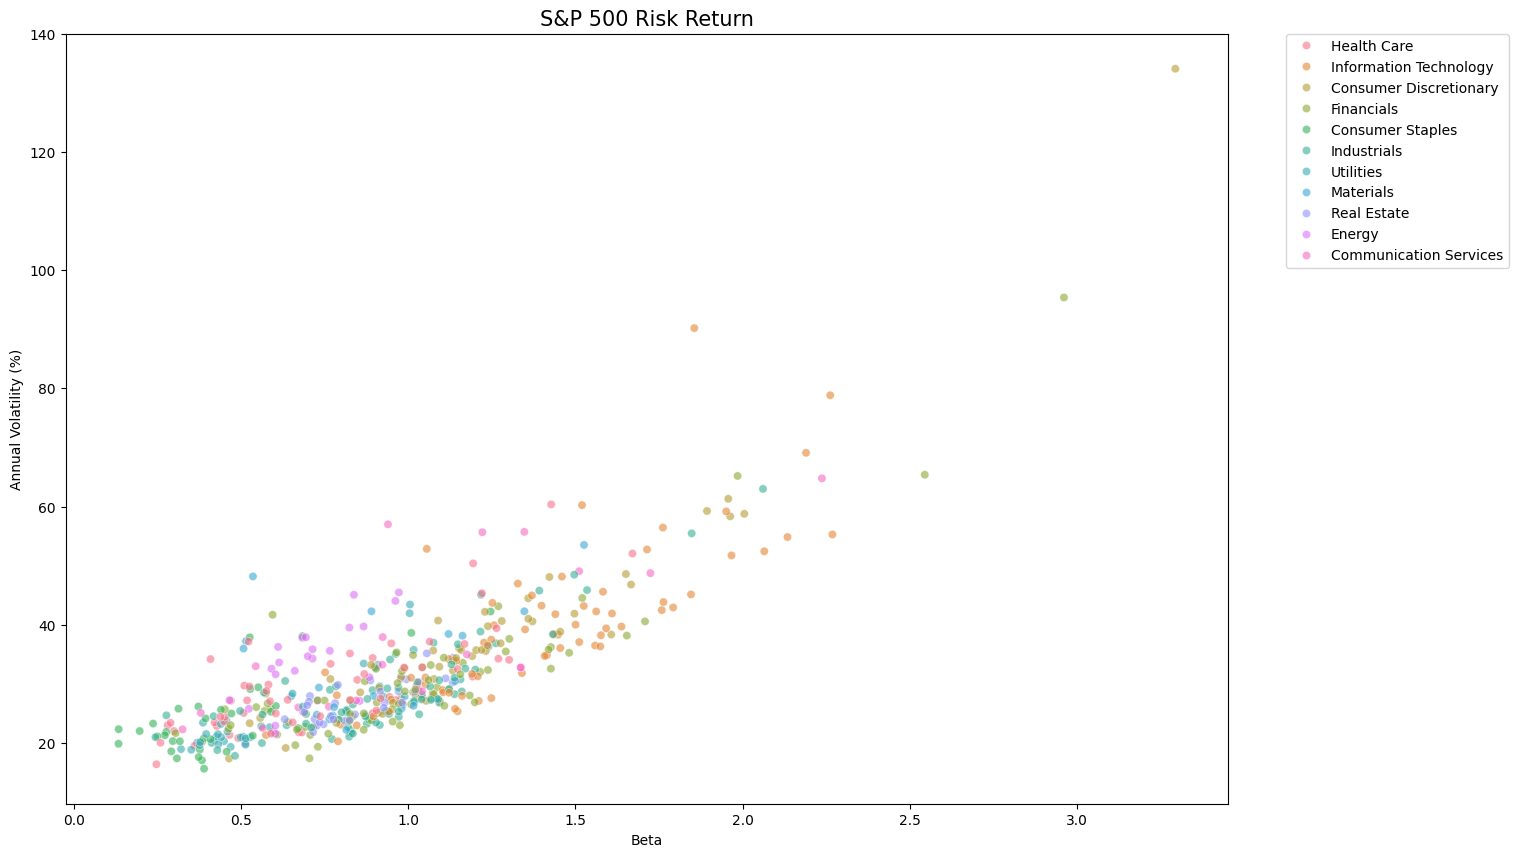

In [8]:
# A.7
# Plots

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))    # creating dimensions

sns.scatterplot(
    data=metrics_df,            # tells the plot where to pull info from
    x='Beta',                   # assigning beta to x axis
    y='Annual_Volatility_Pct',  # assigning annual volatility to y axis
    hue='Sector',               # colour assigns based on sector
    alpha=0.6                   # sets the transparency of the dots
)


plt.title('S&P 500 Risk Return', fontsize=15)                    # plots title
plt.xlabel('Beta')                                               # plots x-axis
plt.ylabel('Annual Volatility (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

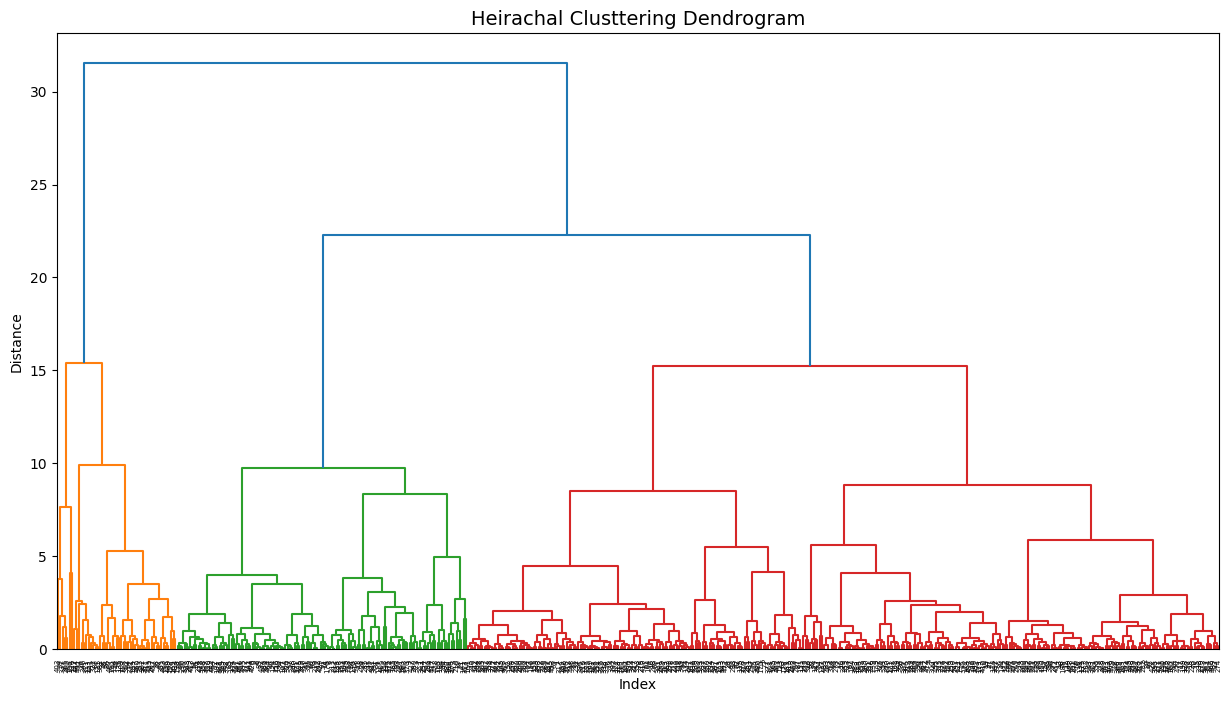

In [9]:
# B.1

import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# scaling the data so beta is not ignored
scaler = StandardScaler()
X_Scaled_Data = scaler.fit_transform(metrics_df[['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']])

# creates dendriogram
plt.figure(figsize=(15, 8))
linkage_data = sch.linkage(X_Scaled_Data, method='ward')
dendrogram = sch.dendrogram(linkage_data)

plt.title('Heirachal Clusttering Dendrogram', fontsize=14)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show

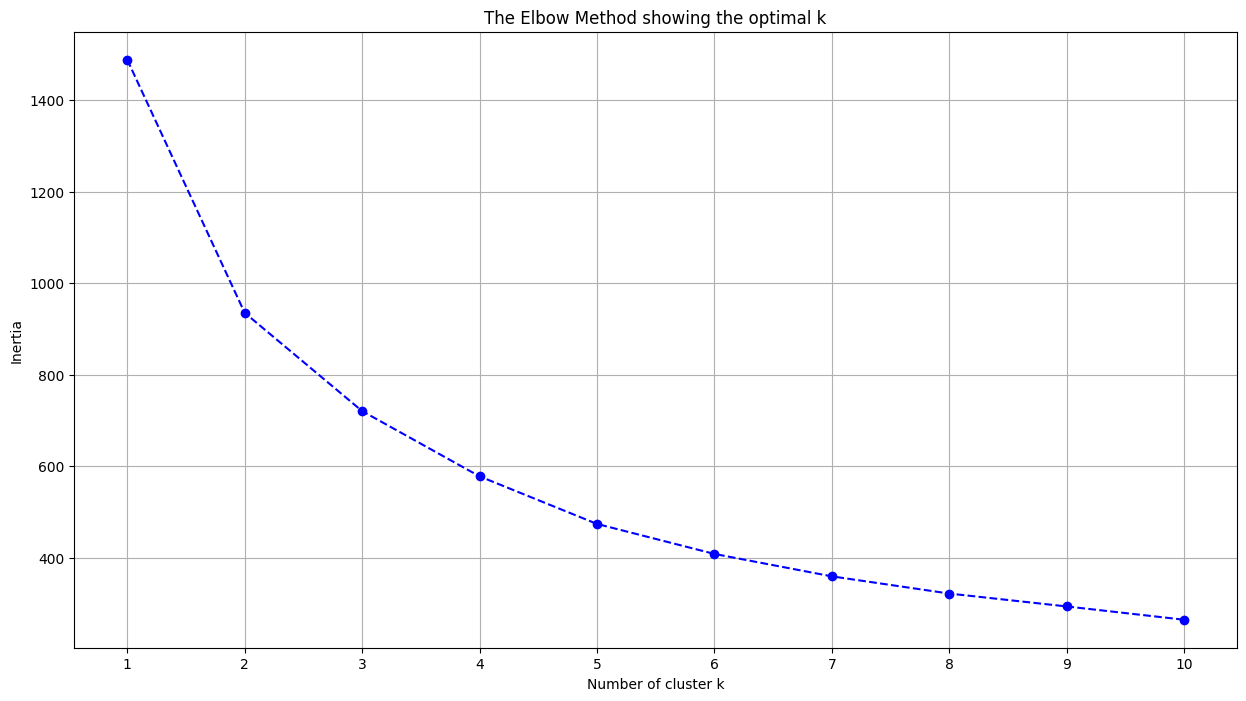

In [10]:
# B.2
# K - means Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# calculating inertia (sum of squared distances to the closest cluster centre)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_Scaled_Data)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph

plt.figure(figsize=(15, 8))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method showing the optimal k')
plt.xlabel('Number of cluster k')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['Cluster'] = final_model.fit(X_Scaled_Data)

Agglomerative Clustering complete.
Cluster label counts:
Agg_Cluster
0    321
1    124
2     51
Name: count, dtype: int64

Cluster profiles (mean values per cluster):
             Mean_Daily_Return_Pct    Beta  Annual_Volatility_Pct
Agg_Cluster                                                      
0                           0.0445  0.7232                25.9383
1                          -0.0023  1.2229                37.0634
2                           0.1541  1.6529                52.2985


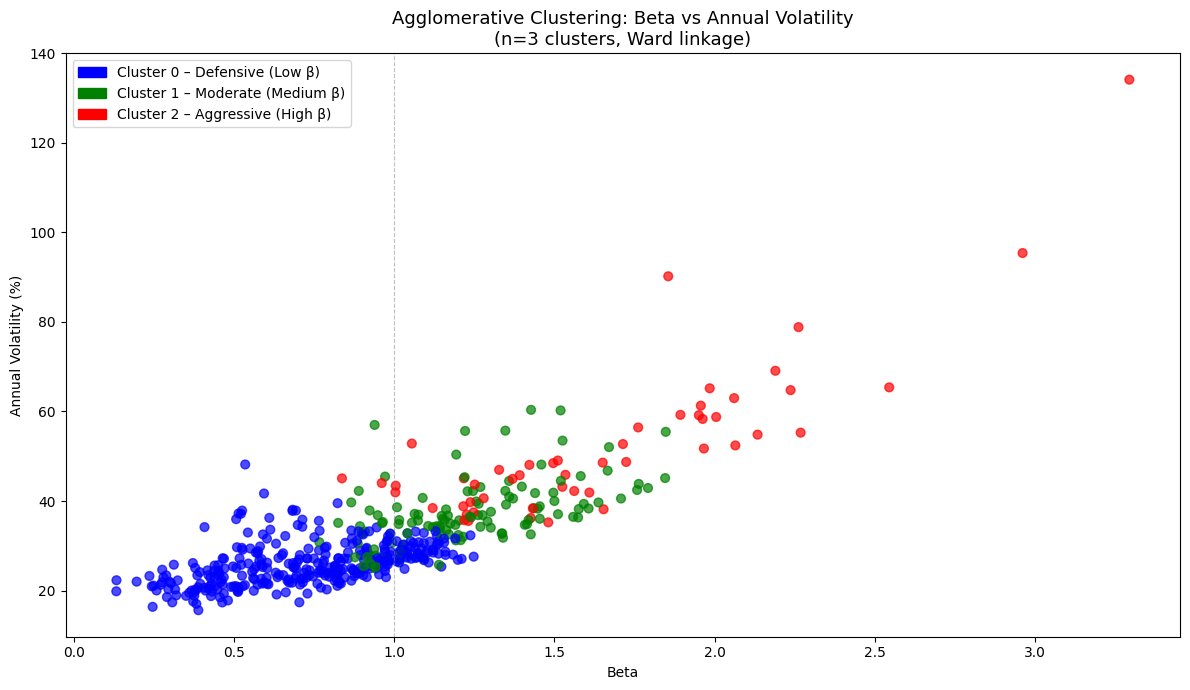

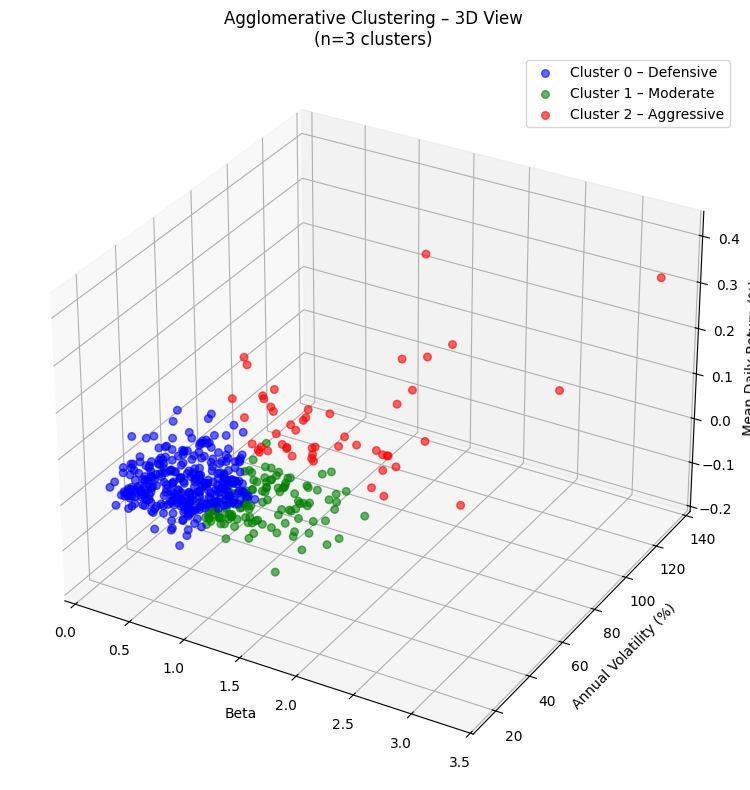


Cluster risk labels assigned:
Agg_Cluster_Label
Defensive (Low β)      321
Moderate (Medium β)    124
Aggressive (High β)     51
Name: count, dtype: int64

Sample stocks per cluster:
  Moderate (Medium β): ['A', 'ABNB', 'ACN', 'ADBE', 'ADI']
  Defensive (Low β): ['AAPL', 'ABBV', 'ABT', 'ACGL', 'ADM']
  Aggressive (High β): ['AMD', 'ANET', 'APO', 'APP', 'ARES']


In [13]:
# B.3  Agglomerative Clustering

# We use n_clusters=3 here, giving us three distinct risk groups.

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

agg_model = AgglomerativeClustering(
    n_clusters=3,        # 3 clusters: Defensive, Moderate, Aggressive
    metric='euclidean',  # standard straight-line distance between points
    linkage='ward'       # same Ward criterion as the dendrogram, for consistency
)

# fit_predict gives arbitrary cluster IDs — we re-map them so that
# cluster 0 = lowest beta (Defensive), 1 = middle (Moderate), 2 = highest beta (Aggressive)
raw_labels = agg_model.fit_predict(X_Scaled_Data)
metrics_df['Agg_Cluster_Raw'] = raw_labels

# Rank raw cluster IDs by their mean beta (ascending)
raw_profile = metrics_df.groupby('Agg_Cluster_Raw')['Beta'].mean().sort_values()
beta_rank_map = {raw_id: new_id for new_id, raw_id in enumerate(raw_profile.index)}
metrics_df['Agg_Cluster'] = metrics_df['Agg_Cluster_Raw'].map(beta_rank_map)

# Apply the re-mapping so cluster 0 is always lowest beta
metrics_df['Agg_Cluster'] = metrics_df['Agg_Cluster_Raw'].map(beta_rank_map)

print("Agglomerative Clustering complete.")
print("Cluster label counts:")
print(metrics_df['Agg_Cluster'].value_counts().sort_index())

# Average risk metrics per cluster — confirms ordering is correct
print("\nCluster profiles (mean values per cluster):")
cluster_profile = metrics_df.groupby('Agg_Cluster')[
    ['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']
].mean().round(4)
print(cluster_profile)

#  2D scatter: Beta vs Annual Volatility
# Cluster 0=blue (Defensive, low β), 1=green (Moderate), 2=red (Aggressive, high β)
import matplotlib.patches as mpatches
cluster_colour_map = {0: 'blue', 1: 'green', 2: 'red'}
point_colours = metrics_df['Agg_Cluster'].map(cluster_colour_map)

plt.figure(figsize=(12, 7))
plt.scatter(
    metrics_df['Beta'],
    metrics_df['Annual_Volatility_Pct'],
    c=point_colours,
    alpha=0.7,
    s=40
)
legend_patches = [
    mpatches.Patch(color='blue',  label='Cluster 0 – Defensive (Low β)'),
    mpatches.Patch(color='green', label='Cluster 1 – Moderate (Medium β)'),
    mpatches.Patch(color='red',   label='Cluster 2 – Aggressive (High β)'),
]
plt.legend(handles=legend_patches)
plt.title('Agglomerative Clustering: Beta vs Annual Volatility\n(n=3 clusters, Ward linkage)', fontsize=13)
plt.xlabel('Beta')
plt.ylabel('Annual Volatility (%)')
plt.axvline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

#  3D scatter: all three dimensions at once
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

colours = {0: 'blue', 1: 'green', 2: 'red'}  # 0=Defensive, 1=Moderate, 2=Aggressive
cluster_names = {0: 'Cluster 0 – Defensive', 1: 'Cluster 1 – Moderate', 2: 'Cluster 2 – Aggressive'}
for cluster_id in sorted(metrics_df['Agg_Cluster'].unique()):
    subset = metrics_df[metrics_df['Agg_Cluster'] == cluster_id]
    ax.scatter(
        subset['Beta'],
        subset['Annual_Volatility_Pct'],
        subset['Mean_Daily_Return_Pct'],
        label=cluster_names[cluster_id],
        color=colours[cluster_id],
        alpha=0.6,
        s=30
    )

ax.set_xlabel('Beta')
ax.set_ylabel('Annual Volatility (%)')
ax.set_zlabel('Mean Daily Return (%)')
ax.set_title('Agglomerative Clustering – 3D View\n(n=3 clusters)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

cluster_labels = {
    0: 'Defensive (Low β)',
    1: 'Moderate (Medium β)',
    2: 'Aggressive (High β)'
}
metrics_df['Agg_Cluster_Label'] = metrics_df['Agg_Cluster'].map(cluster_labels)

print("\nCluster risk labels assigned:")
print(metrics_df['Agg_Cluster_Label'].value_counts())
print("\nSample stocks per cluster:")
for label in metrics_df['Agg_Cluster_Label'].unique():
    sample = metrics_df[metrics_df['Agg_Cluster_Label'] == label].index[:5].tolist()
    print(f"  {label}: {sample}")

# B.4 Appropriateness of K-Means Clustering

The K-means cluster is appropiate here for this analysis for various reasons. It groups stocks based on similarity across multiple numerical features, specifically daily return, beta, and annual volatility.These numeric variables can be can be compared using distance. The main aim here is to group stocks with similar risk and return charactersitics and this is done by placing similar stocks into the same cluster based on how close they are. The data set here includes a relatively large number of rougly 496 stocks. The K means clustering is efficient and relatively easy to implement as it produces clear groupings that can be interpreted in terms of investment behaviour making it suitable for financial analysis

# B5. Choosing the best Cluster and Handling Data Issues
Two key techniques were used to the Elbow Method and the Silhouette Score to determine the optimal number of clusters (k)
The Elbow Method works by plotting the Within-Cluster Sum of Squares (WCSS) against the different values of K. As the number of clusters increases, the WCSS decreases because the clusters become more refined and closer to the data points. However, after a certain point, the improvement starts to slow down. This point is known as the “elbow” and it suggests the most suitable number of clusters, as increasing K further does not significantly improve the model.

The Silhouette Score was also used to support this. It measures how well each stock fits within its assigned cluster compared to other clusters. A higher score means the clusters are more clearly separated and better defined. By comparing the silhouette scores for different values of K, it becomes easier to choose the most appropriate number of clusters.

Before applying K-means, the data needed to be prepared properly. Financial data such as daily returns and volatility can often be skewed and may include extreme values. To deal with this, standardisation ie scaling was applied so that all variables are on the same scale and contribute equally to the clustering process. This is important because without scaling, one variable could dominate the results. Overall, this preprocessing step helps to improve the accuracy and reliability of the clustering results.


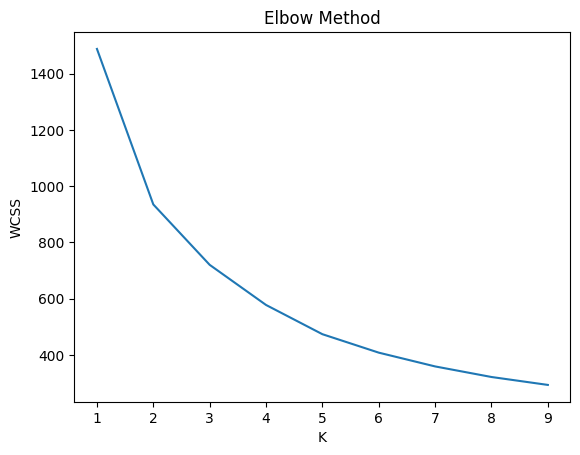

K=2, Score=0.4621945494989208
K=3, Score=0.3109678753729051
K=4, Score=0.32600665179213334
K=5, Score=0.2984666799753462
K=6, Score=0.291380660575362
K=7, Score=0.29398490994612925
K=8, Score=0.29135886202606975
K=9, Score=0.29133533698453656
         Mean_Daily_Return_Pct      Beta  Annual_Volatility_Pct
Cluster                                                        
0                     0.004759  1.170004              35.985758
1                     0.046942  0.692432              25.277772
2                     0.153019  1.705586              53.244112


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use your computed metrics
features = metrics_df[['Mean_Daily_Return_Pct', 'Beta', 'Annual_Volatility_Pct']]

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow Method
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Silhouette Score
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    print(f"K={k}, Score={silhouette_score(scaled_features, labels)}")

# Final clustering (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
metrics_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Cluster summary (IMPORTANT – matches your outputs)
cluster_summary = metrics_df.groupby('Cluster')[[
    'Mean_Daily_Return_Pct',
    'Beta',
    'Annual_Volatility_Pct'
]].mean()

print(cluster_summary)

# B6
The clustering results can be interpreted by grouping the stocks based on their level of risk using beta and annual volatility. Cluster 0 represents the low risk group, where stocks have lower beta values and lower annual volatility. This means they are more stable and do not react as strongly to changes in the market, making them more suitable for risk-averse investors. Cluster 1 represents the moderate risk group, where stocks have medium levels of beta and volatility. These stocks offer a balance between risk and return, meaning they have some growth potential while still maintaining a level of stability. Cluster 2 represents the high risk group, where stocks have higher beta values and higher volatility. These stocks are more sensitive to market movements and experience larger price fluctuations. Although they carry more risk, they also have the potential for higher returns. Overall, the clustering helps to clearly separate stocks based on their risk and return characteristics, making it easier to understand different investment behaviours.

# C1

A data mart for S&P 500 analysis should adopt a star schema to support performance tracking and segmentation.

Dimensions:

Time: date, month, quarter, year for trend analysis.
Company: sector, industry, market capitalization.
Geography: headquarters location (country/region) to identify high and low value markets.
Investor Segment (Python-derived): institutional vs retail clusters identified via trading volume and frequency.
Market Conditions: interest rates, inflation, volatility index levels.

Metrics (Facts):

Stock prices (open, close, high, low) - helps to capture daily price movements to help analyse trends
Trading volume and liquidity - Volume as the name suggest shows how much trade was done and the liquidity shows how much stocks could easily be sold
Returns (daily, monthly, annual) - Profitabily is measured on the investments over a period
Volatility and beta (risk indicators) - reflects price fluctuations
Market capitalization and earnings (EPS, P/E ratio)

Business Value Segmentation (Python):
Using clustering (e.g., K-means), companies or investors can be grouped by return, risk, and volume. High-return, low-volatility segments represent premium investment opportunities, while high-volume regions indicate strong liquidity and institutional interest.

Justification:
These dimensions and metrics enable investors to identify profitable sectors, assess risk, and target high-value geographic or investor segments, improving portfolio optimization and strategic decision-making.
